In [282]:
# Statistiques descriptives et inférence statistique
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

temps_de_jeu = []
with open("TempsDeJeu.txt", "r", encoding="utf-8") as f:
    temps_de_jeu = np.array(
        [int(float(ligne.strip())) for ligne in f]
    )
    
moyenne = np.mean(temps_de_jeu)
mediane = np.median(temps_de_jeu)
ecart_type = np.std(temps_de_jeu)
mode = np.bincount(temps_de_jeu).argmax()
minimum = np.min(temps_de_jeu)
maximum = np.max(temps_de_jeu)
etendue = maximum - minimum

print("I")
print(f"Moyenne\t\t: {moyenne}")
print(f"Médiane\t\t: {mediane}")
print(f"Écart-type\t: {ecart_type:.2f}")
print(f"Mode\t\t: {mode}")
print(f"Minimum\t\t: {minimum}")
print(f"Maximum\t\t: {maximum}")
print(f"Étendue\t\t: {etendue}")

I
Moyenne		: 280.58
Médiane		: 279.0
Écart-type	: 50.12
Mode		: 253
Minimum		: 148
Maximum		: 382
Étendue		: 234


II


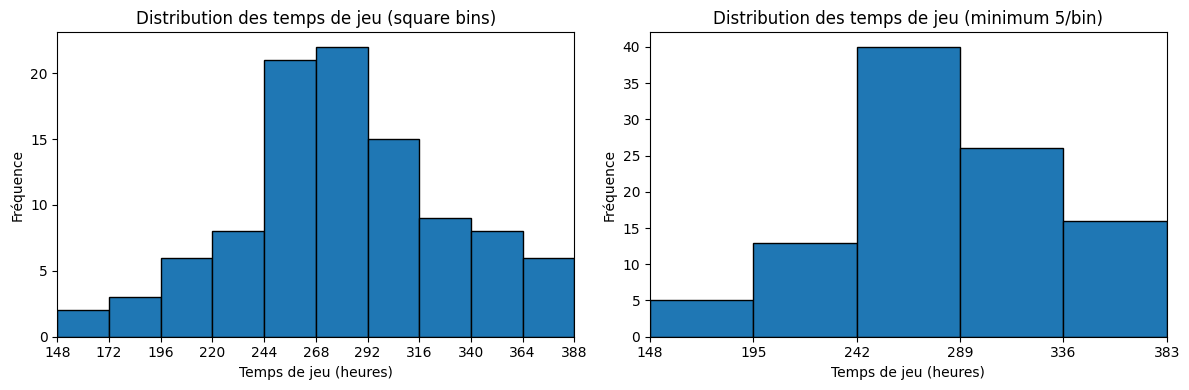

Tableau des classes
| Classe	| Limites	| centres	| Fréquences	| Fréquences relatives	| Fréquences cumulées	|
| 1		| [148, 172[	| 159.5		| 2		| 0.0200		| 0.0200		|
-----------------------------------------------------------------------------------------------------------------
| 2		| [172, 196[	| 183.5		| 3		| 0.0300		| 0.0500		|
-----------------------------------------------------------------------------------------------------------------
| 3		| [196, 220[	| 207.5		| 6		| 0.0600		| 0.1100		|
-----------------------------------------------------------------------------------------------------------------
| 4		| [220, 244[	| 231.5		| 8		| 0.0800		| 0.1900		|
-----------------------------------------------------------------------------------------------------------------
| 5		| [244, 268[	| 255.5		| 21		| 0.2100		| 0.4000		|
-----------------------------------------------------------------------------------------------------------------
| 6		| [268, 292[	| 279.5		| 22		| 0.2200		| 0.620

In [283]:
print("II")

nb_bins = np.sqrt(len(temps_de_jeu)).astype(int)
bin_width = etendue // nb_bins + 1
histogram_max = bin_width * nb_bins + minimum + 1

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(temps_de_jeu, bins=np.arange(minimum, histogram_max, bin_width), edgecolor="black")
plt.xticks(range(minimum, histogram_max, bin_width))
plt.title("Distribution des temps de jeu (square bins)")
plt.xlabel("Temps de jeu (heures)")
plt.xlim(minimum, histogram_max - 1)
plt.ylabel("Fréquence")


minbin = 5
minbinwidth = etendue // minbin + 1
minhistmax = minbinwidth * minbin + minimum + 1

plt.subplot(1, 2, 2)
plt.hist(temps_de_jeu, bins=np.arange(minimum, minhistmax, minbinwidth), edgecolor="black")
plt.xticks(range(minimum, minhistmax, minbinwidth))
plt.title("Distribution des temps de jeu (minimum 5/bin)")
plt.xlabel("Temps de jeu (heures)")
plt.xlim(minimum, minhistmax - 1)
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

print("Tableau des classes")
print("="*113)
print("| Classe\t| Limites\t| centres\t| Fréquences\t| Fréquences relatives\t| Fréquences cumulées\t|")
print("="*113)

classes = []
for i in range(nb_bins):
    classe_min = minimum + i * bin_width
    classe_max = classe_min + bin_width - 1
    centre = (classe_min + classe_max) / 2
    frequence = np.sum((temps_de_jeu >= classe_min) & (temps_de_jeu <= classe_max))
    frequence_relative = frequence / len(temps_de_jeu)
    frequence_cumulee = np.sum((temps_de_jeu <= classe_max)) / len(temps_de_jeu)
    classes.append(frequence)
    print(f"| {i+1}\t\t| [{classe_min}, {classe_max+1}[\t| {centre}\t\t| {frequence}\t\t| {frequence_relative:.4f}\t\t| {frequence_cumulee:.4f}\t\t|")
    print("-"*113)
    

In [284]:
print("III")
alpha = 0.05 # significance
n = nb_bins
df = n - 1
critical_value = stats.chi2.ppf(1 - alpha, df)

print(f"Degré de liberté (df) = {df}")
print(f"Valeur critique pour alpha={alpha} : {critical_value:.4f}")
print(minimum, maximum)

# Bornes pour map les probabilité cdf entre eux
bornes = minimum + np.arange(nb_bins + 1) * bin_width

# Probabilité de chaque intervalle
probabilites = (
    stats.norm.cdf(bornes[1:], loc=moyenne, scale=ecart_type)
    - stats.norm.cdf(bornes[:-1], loc=moyenne, scale=ecart_type)
)

# Conversion en effectifs attendus par classe
classes_normales = (probabilites * 100).tolist()

ki2 = 0
for i in range(len(classes)):
    ki2 += (classes[i] - classes_normales[i]) ** 2 / classes_normales[i]
    
print(f"Statistique du khi2 : {ki2:.4f}")

III
Degré de liberté (df) = 9
Valeur critique pour alpha=0.05 : 16.9190
148 382
Statistique du khi2 : 7.3254


IV
Interval de confiance pour la moyenne à 95% : [182.3360, 378.8240]


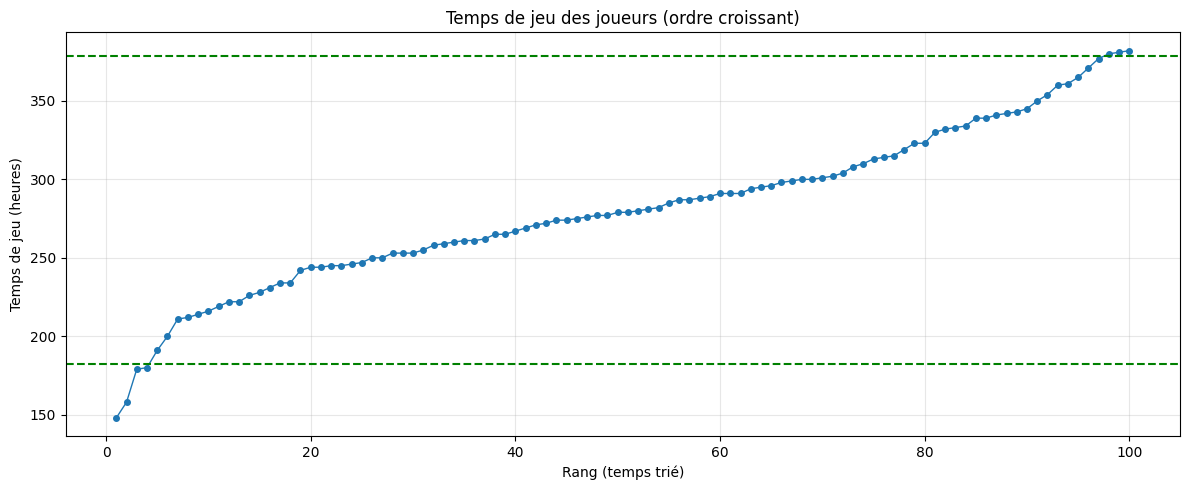

In [285]:
print("IV")
niveau_confiance = 0.95 # 1-alpha ou encore P(x1 < X < x2) (en pourcentage)
# Cote Z de notre niveau de confiance
# soit le Z entre 0 < Z < z (indice alpha/2)
# donc indice de 0.05 /2 => 0.025
z = 1.96 # valeur tabulée de la loi normale centrée réduite pour 95%

marge_erreur = z * ecart_type
borne_inferieure = moyenne - marge_erreur
borne_superieure = moyenne + marge_erreur

print(f"Interval de confiance pour la moyenne à 95% : [{borne_inferieure:.4f}, {borne_superieure:.4f}]")

plt.figure(figsize=(12, 5))
plt.plot(np.arange(1, len(temps_de_jeu) + 1), np.sort(temps_de_jeu), marker="o", linestyle="-", linewidth=1, markersize=4)
plt.title("Temps de jeu des joueurs (ordre croissant)")
plt.xlabel("Rang (temps trié)")
plt.ylabel("Temps de jeu (heures)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.axhline(borne_inferieure, color="green", linestyle="dashed", label="Moyenne")
plt.axhline(borne_superieure, color="green", linestyle="dashed", label="Moyenne")
plt.show()

In [286]:
print("V")

n = len(temps_de_jeu)
moyenne_estime = 300 # 5h
z = -1.645 # Z pour le 5% dans la table (voir IV)

ecart_type_approprie = ecart_type / np.sqrt(n) # S / sqrt(n)
valeur_critique = z * ecart_type_approprie + moyenne_estime

print("Moyenne\t\t: ", moyenne)
print("Valeur Critique\t: ", valeur_critique)
print("Conclusion\t: ", "Rejet de l'hypothèse nulle" if moyenne < valeur_critique else "Non rejet de l'hypothèse nulle")

print(f"L'erreur de première espèce (alpha) est de 5% puisque le seuil est à 95%")

V
Moyenne		:  280.58
Valeur Critique	:  291.75452286814766
Conclusion	:  Rejet de l'hypothèse nulle
L'erreur de première espèce (alpha) est de 5% puisque le seuil est à 95%


In [287]:
print("VI")
z = (valeur_critique - moyenne) / ecart_type_approprie 

print("Nouveau Z ajusté à la moyenne échantillonnale : ", z)

probabilite = 0.9867 # Trouvé dans la table de la loi normale centrée réduite pour Z = 2.22
pourcentage = 1 - probabilite

print(f"Probabilité d'accepter une fausse valeur sur l'hypothèse nulle : {pourcentage:.4f} ({pourcentage*100:.2f}%)")

VI
Nouveau Z ajusté à la moyenne échantillonnale :  2.2293543265183233
Probabilité d'accepter une fausse valeur sur l'hypothèse nulle : 0.0133 (1.33%)


In [288]:
print("VII")

n = len(temps_de_jeu)
ecart_type_estime = 50
print(f"Écart-type estimé : {ecart_type_estime}")
print(f"Écart-type observé : {ecart_type:.2f}")
x2 = (n - 1) * (ecart_type ** 2) / (ecart_type_estime ** 2)

borne_inferieure = 77.93 # Trouvé dans la table du khi2 pour df = 99 ~ 100 et alpha = 97.5%
borne_superieure = 129.56 # Trouvé dans la table du khi2 pour df = 99 ~ 100 et alpha = 2.5%

print(f"Borne supérieure : {borne_superieure:.2f}")
print(f"Statistique de test de la variance bilatérale : {x2:.4f}")
print(f"Borne inférieure : {borne_inferieure:.2f}")

print(f"Confirme l'Hypothèse, car elle est entre les deux bornes: {borne_inferieure:.2f} < {x2:.2f} < {borne_superieure:.2f}")

VII
Écart-type estimé : 50
Écart-type observé : 50.12
Borne supérieure : 129.56
Statistique de test de la variance bilatérale : 99.4936
Borne inférieure : 77.93
Confirme l'Hypothèse, car elle est entre les deux bornes: 77.93 < 99.49 < 129.56
